## 1. Cleaned dataset


In [1]:
import pandas as pd
import numpy as np

from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.model_selection import train_test_split

import warnings
warnings.filterwarnings("ignore")

## 1.1 Loading data

In [2]:
df = pd.read_csv('/content/primary_google_beauty_reviews_cleaned.csv')
df.head()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2894 entries, 0 to 2893
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   review_id        2894 non-null   int64 
 1   business_id      2894 non-null   object
 2   stars            2894 non-null   int64 
 3   sentiment_label  2894 non-null   object
 4   clean_text       2894 non-null   object
 5   processed_text   2892 non-null   object
 6   date             2894 non-null   object
dtypes: int64(2), object(5)
memory usage: 158.4+ KB


The cleaned dataset from Phase 2 was loaded into the notebook. This dataset contains preprocessed textual reviews along with their corresponding sentiment labels. Initial inspection was performed to understand the structure of the dataset and verify that all required columns are available for the modelling phase.

## 1.2 Selecting features & target

In [3]:
text_col = "processed_text"
target_col = "sentiment_label"

Only the relevant columns were selected for modelling. The 'processed_text' column was chosen as the input feature since it contains cleaned and preprocessed textual data. The 'sentiment_label' column was selected as the target variable, representing the sentiment class for each review. All missing values were removed to ensure data quality and prevent errors during the modelling process.

## 1.3 Spreating X and Y

In [4]:
df = df[[text_col, target_col]].dropna()

X_text = df[text_col].astype(str)
y = df[target_col]

The dataset was divided into two main components: the input feature (X_text), which contains the processed textual reviews, and the target variable (y), which contains the corresponding sentiment labels. This separation is necessary for training machine learning models.

In [5]:
print(df.shape)
print(X_text.head())
print(y.head())

(2892, 2)
0    finally went liberty london amazing store ente...
1    really nice shopping day liberty christmas dec...
2    liberty destination dream anyone sews stitch e...
3    beautiful store amazing range age amazing hist...
4    cool building inside really came cruella movie...
Name: processed_text, dtype: object
0    Positive
1    Positive
2    Positive
3    Positive
4    Positive
Name: sentiment_label, dtype: object


## 1.4 Bag of words (BOW)

In [6]:
bow_vectorizer = CountVectorizer()
X_bow = bow_vectorizer.fit_transform(X_text)

In [7]:
print("Bag of Words shape:", X_bow.shape)
print("Number of BOW features:", len(bow_vectorizer.get_feature_names_out()))

Bag of Words shape: (2892, 8594)
Number of BOW features: 8594


The Bag of Words technique was applied to convert textual data into numerical form. This method represents each review as a vector based on the frequency of words appearing in the dataset. It allows machine learning models to process text by transforming it into a structured numerical format.


## 1.5 TF-IDF

In [8]:
tfidf_vectorizer = TfidfVectorizer()
X_tfidf = tfidf_vectorizer.fit_transform(X_text)

In [9]:
print("TF-IDF shape:", X_tfidf.shape)
print("Number of TF-IDF features:", len(tfidf_vectorizer.get_feature_names_out()))

TF-IDF shape: (2892, 8594)
Number of TF-IDF features: 8594


TF-IDF (Term Frequency–Inverse Document Frequency) was applied as an alternative text representation technique. Unlike Bag of Words, TF-IDF assigns higher importance to words that are more informative and less frequent across the dataset. This helps improve model performance by reducing the impact of common and less meaningful words.

## 1.6 Train-Test split

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X_tfidf,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [11]:
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (2313, 8594)
X_test shape: (579, 8594)
y_train shape: (2313,)
y_test shape: (579,)


The dataset was split into training and testing sets using an 80/20 ratio. A fixed random state was used to ensure reproducibility of results. Stratified sampling was applied to preserve the distribution of sentiment classes across both sets, ensuring a fair and balanced evaluation of the models.

## Baseline Model – Logistic Regression

A baseline classification model was implemented using Logistic Regression to establish a reference performance for sentiment classification.

The processed review text was converted into numerical features using TF-IDF vectorization. The dataset was split into training and testing sets, and the model was trained on the training data and evaluated on unseen test data.

Evaluation metrics include accuracy, precision, recall, and F1-score, along with a confusion matrix to analyze class-wise performance.

In [12]:
from sklearn.linear_model import LogisticRegression

baseline_model = LogisticRegression(max_iter=1000)

baseline_model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [13]:
y_pred_baseline = baseline_model.predict(X_test)

In [14]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

accuracy = accuracy_score(y_test, y_pred_baseline)
precision = precision_score(y_test, y_pred_baseline, average='weighted')
recall = recall_score(y_test, y_pred_baseline, average='weighted')
f1 = f1_score(y_test, y_pred_baseline, average='weighted')

print("Baseline Model Performance:")
print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1-score:", f1)

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_baseline))

Baseline Model Performance:
Accuracy: 0.918825561312608
Precision: 0.9014897616182511
Recall: 0.918825561312608
F1-score: 0.9040803755829664

Classification Report:

              precision    recall  f1-score   support

    Negative       0.95      0.63      0.76        87
     Neutral       0.00      0.00      0.00        12
    Positive       0.92      0.99      0.95       480

    accuracy                           0.92       579
   macro avg       0.62      0.54      0.57       579
weighted avg       0.90      0.92      0.90       579



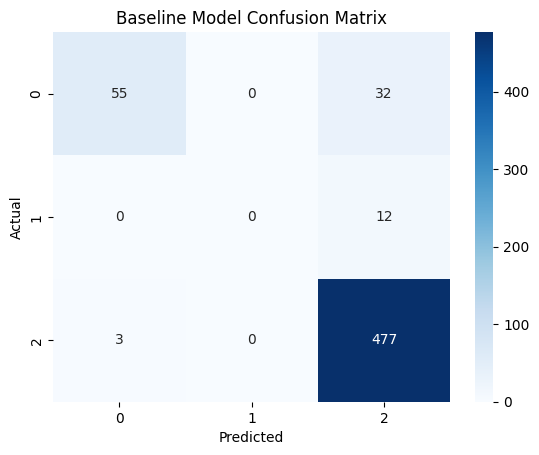

In [15]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred_baseline)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Baseline Model Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

---
## Advanced Model 1: Support Vector Machine (SVM)
----

In [16]:
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

In [17]:
svm_model = LinearSVC(random_state=42)

In [18]:
svm_model.fit(X_train, y_train)
print("SVM model trained successfully.")

SVM model trained successfully.


In [19]:
y_pred_svm = svm_model.predict(X_test)
print("Predictions completed.")

Predictions completed.


This section presents the performance of the SVM model.  
The model was trained on the training dataset and evaluated using accuracy, precision, recall, and F1-score.  
The confusion matrix is also provided to visualize the classification performance.

In [20]:
svm_accuracy = accuracy_score(y_test, y_pred_svm)
print("SVM Accuracy:", svm_accuracy)

SVM Accuracy: 0.9430051813471503


In [21]:
report = classification_report(y_test, y_pred_svm, output_dict=True)
report_df = pd.DataFrame(report).transpose()

report_df

,precision,recall,f1-score,support
Negative,0.890244,0.839080,0.863905,87.000000
Neutral,1.000000,0.083333,0.153846,12.000000
Positive,0.951613,0.983333,0.967213,480.000000
accuracy,0.943005,0.943005,0.943005,0.943005
macro avg,0.947286,0.635249,0.661655,579.000000
weighted avg,0.943394,0.943005,0.934833,579.000000


In [22]:
from sklearn.metrics import confusion_matrix

svm_cm = confusion_matrix(y_test, y_pred_svm)

# ينحذفففف

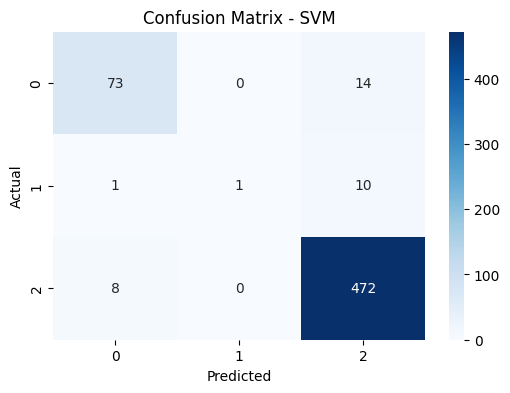

In [23]:
# Confusion Matrix
plt.figure(figsize=(6,4))
sns.heatmap(svm_cm, annot=True, fmt='d', cmap='Blues')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - SVM")

plt.show()

## Advanced Model 2: Random Forest

In this section, we use the Random Forest algorithm as an additional model for sentiment classification. Random Forest combines multiple decision trees to improve prediction accuracy and reduce errors.

The model is trained using TF-IDF features and evaluated using accuracy, precision, recall, F1-score, and a confusion matrix.

In [24]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

In [25]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

In [26]:
rf_model.fit(X_train, y_train)
print("Random Forest model trained successfully.")

Random Forest model trained successfully.


In [27]:
y_pred_rf = rf_model.predict(X_test)
print("Predictions completed.")

Predictions completed.


In [28]:
rf_accuracy = accuracy_score(y_test, y_pred_rf)
rf_precision = precision_score(y_test, y_pred_rf, average='weighted')
rf_recall = recall_score(y_test, y_pred_rf, average='weighted')
rf_f1 = f1_score(y_test, y_pred_rf, average='weighted')

In [29]:
print("Random Forest Performance:")
print("Accuracy:", rf_accuracy)
print("Precision:", rf_precision)
print("Recall:", rf_recall)
print("F1-score:", rf_f1)

print("\nClassification Report:\n")
import pandas as pd
rf_report = classification_report(y_test, y_pred_rf, output_dict=True)
rf_df = pd.DataFrame(rf_report).transpose()
rf_df

Random Forest Performance:
Accuracy: 0.918825561312608
Precision: 0.9005343475353135
Recall: 0.918825561312608
F1-score: 0.9040897153807934

Classification Report:



,precision,recall,f1-score,support
Negative,0.932203,0.632184,0.753425,87.000000
Neutral,0.000000,0.000000,0.000000,12.000000
Positive,0.917308,0.993750,0.954000,480.000000
accuracy,0.918826,0.918826,0.918826,0.918826
macro avg,0.616504,0.541978,0.569142,579.000000
weighted avg,0.900534,0.918826,0.904090,579.000000


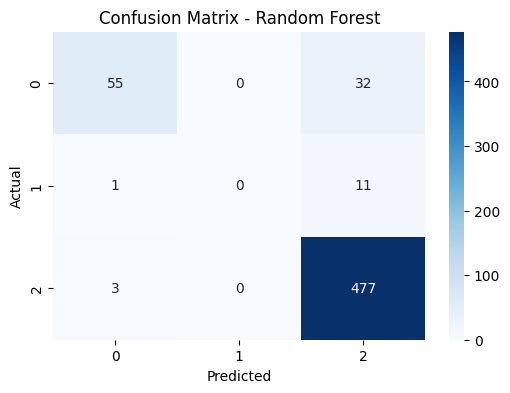

In [30]:
rf_cm = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(6,4))
sns.heatmap(rf_cm, annot=True, fmt='d', cmap='Blues')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Random Forest")

plt.show()

## Model Evaluation & Selection


In this section, the performance of all models is compared to determine the best model for sentiment classification. The models are evaluated using accuracy, precision, recall, and F1-score.

Based on the results, the SVM model achieved the highest performance compared to the other models. Therefore, it was selected as the final model for prediction.

In [31]:
import pandas as pd

results = pd.DataFrame({
    "Model": ["Logistic Regression", "SVM", "Random Forest"],

    "Accuracy": [
        accuracy,
        svm_accuracy,
        rf_accuracy
    ],

    "Precision": [
        precision,
        report_df.loc["weighted avg", "precision"],
        rf_precision
    ],

    "Recall": [
        recall,
        report_df.loc["weighted avg", "recall"],
        rf_recall
    ],

    "F1-score": [
        f1,
        report_df.loc["weighted avg", "f1-score"],
        rf_f1
    ]
})

results

,Model,Accuracy,Precision,Recall,F1-score
0,Logistic Regression,0.918826,0.901490,0.918826,0.904080
1,SVM,0.943005,0.943394,0.943005,0.934833
2,Random Forest,0.918826,0.900534,0.918826,0.904090


In [32]:
import pandas as pd

results = pd.DataFrame({
    "Model": ["Logistic Regression", "SVM (LinearSVC)", "Random Forest"],

    "Accuracy": [accuracy, svm_accuracy, rf_accuracy],

    "Precision": [
        precision,
        report_df.loc["weighted avg", "precision"],
        rf_precision
    ],

    "Recall": [
        recall,
        report_df.loc["weighted avg", "recall"],
        rf_recall
    ],

    "F1-score": [
        f1,
        report_df.loc["weighted avg", "f1-score"],
        rf_f1
    ]
})

results = results.round(4)

results_sorted = results.sort_values(by="F1-score", ascending=False)

best_model = results_sorted.iloc[0]

print("="*60)
print("MODEL COMPARISON RESULTS")
print("="*60)
print(results_sorted)

print("\n" + "="*60)
print("BEST PERFORMING MODEL (Based on F1-score)")
print("="*60)
print(best_model)

MODEL COMPARISON RESULTS
                 Model  Accuracy  Precision  Recall  F1-score
1      SVM (LinearSVC)    0.9430     0.9434  0.9430    0.9348
0  Logistic Regression    0.9188     0.9015  0.9188    0.9041
2        Random Forest    0.9188     0.9005  0.9188    0.9041

BEST PERFORMING MODEL (Based on F1-score)
Model        SVM (LinearSVC)
Accuracy               0.943
Precision             0.9434
Recall                 0.943
F1-score              0.9348
Name: 1, dtype: object


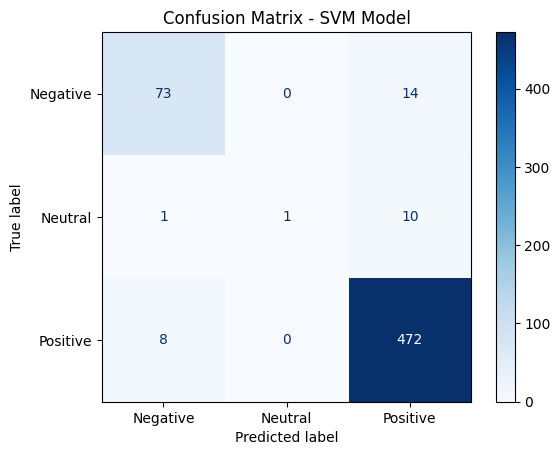

In [33]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt


cm = confusion_matrix(y_test, y_pred_svm)

disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=svm_model.classes_)

disp.plot(cmap="Blues", values_format="d")

plt.title("Confusion Matrix - SVM Model")
plt.show()

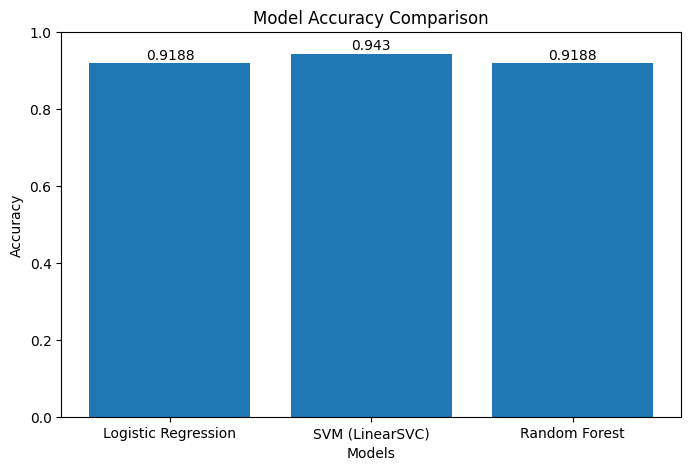

In [34]:
import matplotlib.pyplot as plt

models = ["Logistic Regression", "SVM (LinearSVC)", "Random Forest"]
accuracies = [accuracy, svm_accuracy, rf_accuracy]

plt.figure(figsize=(8,5))
plt.bar(models, accuracies)

plt.title("Model Accuracy Comparison")
plt.xlabel("Models")
plt.ylabel("Accuracy")
plt.ylim(0, 1)

for i, v in enumerate(accuracies):
    plt.text(i, v + 0.01, str(round(v, 4)), ha='center')

plt.show()

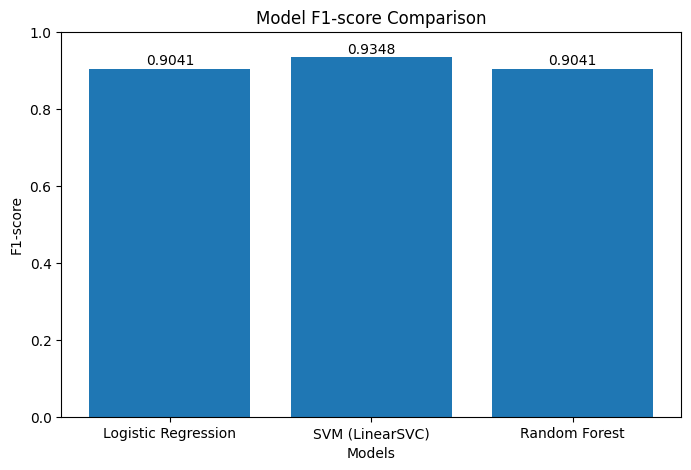

In [35]:

models = ["Logistic Regression", "SVM (LinearSVC)", "Random Forest"]
f1_scores = [f1, report_df.loc["weighted avg", "f1-score"], rf_f1]

plt.figure(figsize=(8,5))
plt.bar(models, f1_scores)

plt.title("Model F1-score Comparison")
plt.xlabel("Models")
plt.ylabel("F1-score")
plt.ylim(0, 1)

for i, v in enumerate(f1_scores):
    plt.text(i, v + 0.01, str(round(v, 4)), ha='center')

plt.show()

The SVM (LinearSVC) model was selected as the best-performing model because it achieved the highest F1-score compared to Logistic Regression and Random Forest. Since F1-score balances both precision and recall, it provides a more reliable measure of performance, especially for classification tasks. Additionally, SVM also showed the highest accuracy, precision, and recall, indicating consistent and strong performance across all evaluation metrics.

# Trying the selected model with new unseen data

The selected SVM model was also tested on new unseen reviews. It produced reasonable predictions for clearly positive and clearly negative examples. However, prediction of the neutral class remained unreliable due to the limited number of neutral samples in the training data.

In [47]:
# New unseen reviews
new_reviews = [
    "The staff were friendly, professional, and the salon was very clean",
    "Terrible service, rude staff, dirty place, and I will never come back",
    "The experience was average, not bad but not great"
]

In [50]:
import re
import nltk
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

stop_words = set(stopwords.words('english'))

lemmatizer = WordNetLemmatizer()

def preprocess_new_review(text):
    text = text.lower()
    text = re.sub(r'http\S+', '', text)
    text = re.sub(r'[^a-z\s]', '', text)
    tokens = text.split()
    tokens = [word for word in tokens if word not in stop_words]
    tokens = [lemmatizer.lemmatize(word) for word in tokens]
    return " ".join(tokens)

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


In [51]:
# Apply same preprocessing
new_reviews_processed = [preprocess_new_review(text) for text in new_reviews]
# Transform using the same fitted TF-IDF vectorizer
new_reviews_tfidf = tfidf_vectorizer.transform(new_reviews_processed)
# Predict using the selected best model (SVM)
new_predictions = svm_model.predict(new_reviews_tfidf)

for original, processed, pred in zip(new_reviews, new_reviews_processed, new_predictions):
    print("Original:", original)
    print("Processed:", processed)
    print("Predicted:", pred)
    print("-" * 50)

Original: The staff were friendly, professional, and the salon was very clean
Processed: staff friendly professional salon clean
Predicted: Positive
--------------------------------------------------
Original: Terrible service, rude staff, dirty place, and I will never come back
Processed: terrible service rude staff dirty place never come back
Predicted: Negative
--------------------------------------------------
Original: The experience was average, not bad but not great
Processed: experience average bad great
Predicted: Positive
--------------------------------------------------
